
# Part C: Baseline Model – K-Nearest Neighbors (KNN)

In [3]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)



In [4]:

df = pd.read_excel("Message_Intelligence_Dataset_5200.xlsx")

print("Dataset Shape:", df.shape)


Dataset Shape: (5200, 16)


In [5]:

target_col = "spam_label"


In [6]:

drop_cols = []

for col in ['message_id','message_text','timestamp']:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=[target_col] + drop_cols)

y = df[target_col]


In [7]:

imputer = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)


In [8]:

scaler = StandardScaler()

X = scaler.fit_transform(X)


In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape: (4160, 12)
Testing Shape : (1040, 12)


In [10]:

k_values = range(1,21)

accuracy_scores = []

for k in k_values:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    accuracy_scores.append(acc)


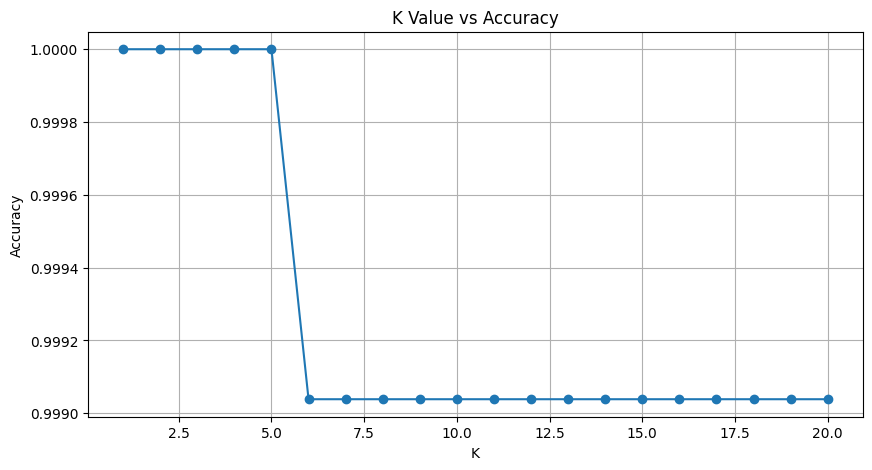

In [11]:

plt.figure(figsize=(10,5))

plt.plot(
    k_values,
    accuracy_scores,
    marker='o'
)

plt.title("K Value vs Accuracy")
plt.xlabel("K")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()


In [12]:

best_k = k_values[
    np.argmax(accuracy_scores)
]

print("Best K:", best_k)


Best K: 1


In [13]:

knn = KNeighborsClassifier(
    n_neighbors=best_k
)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)


In [14]:

acc = accuracy_score(
    y_test,
    y_pred
)

print("Final Accuracy:", acc)


Final Accuracy: 1.0


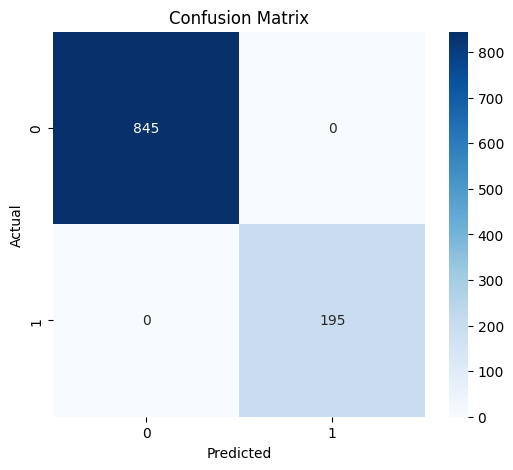

In [15]:

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [16]:

print(classification_report(
    y_test,
    y_pred
))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



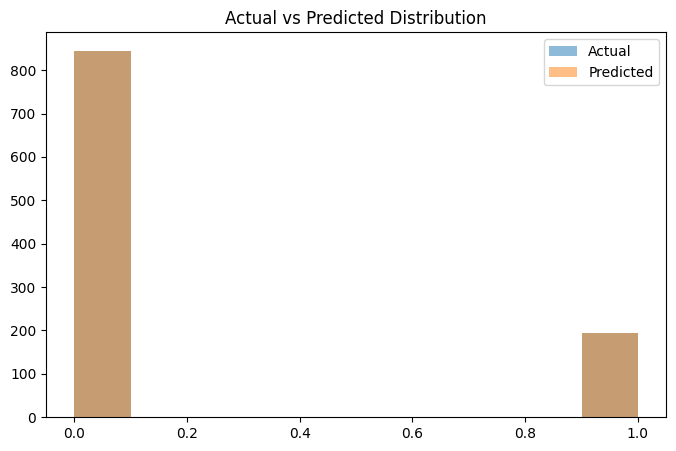

In [17]:

plt.figure(figsize=(8,5))

plt.hist(
    y_test,
    alpha=0.5,
    label='Actual'
)

plt.hist(
    y_pred,
    alpha=0.5,
    label='Predicted'
)

plt.legend()

plt.title(
    "Actual vs Predicted Distribution"
)

plt.show()


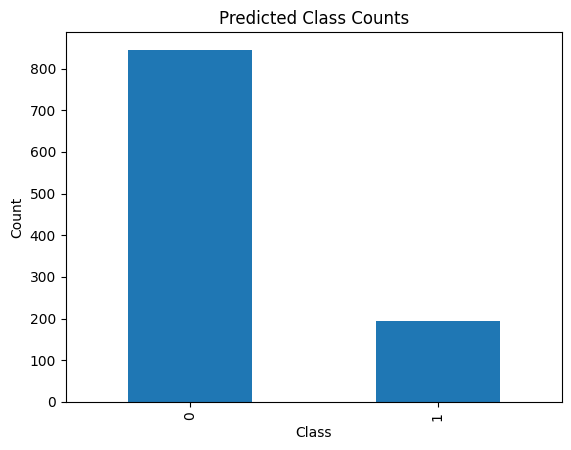

In [18]:

pd.Series(y_pred).value_counts().plot(
    kind='bar'
)

plt.title("Predicted Class Counts")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [19]:

knn_e = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean'
)

knn_e.fit(X_train, y_train)

pred_e = knn_e.predict(X_test)

acc_e = accuracy_score(
    y_test,
    pred_e
)


In [20]:

knn_m = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='manhattan'
)

knn_m.fit(X_train, y_train)

pred_m = knn_m.predict(X_test)

acc_m = accuracy_score(
    y_test,
    pred_m
)

print("Euclidean Accuracy :", acc_e)
print("Manhattan Accuracy :", acc_m)


Euclidean Accuracy : 1.0
Manhattan Accuracy : 1.0


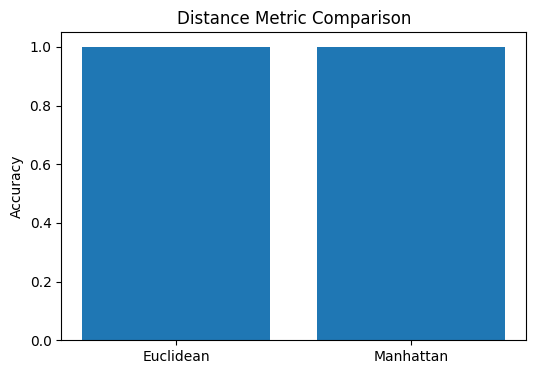

In [21]:

plt.figure(figsize=(6,4))

plt.bar(
    ['Euclidean','Manhattan'],
    [acc_e, acc_m]
)

plt.title(
    "Distance Metric Comparison"
)

plt.ylabel("Accuracy")

plt.show()


In [22]:

misclassified = np.sum(
    y_test != y_pred
)

correct = len(y_test) - misclassified

print("Misclassified:", misclassified)



Misclassified: 0


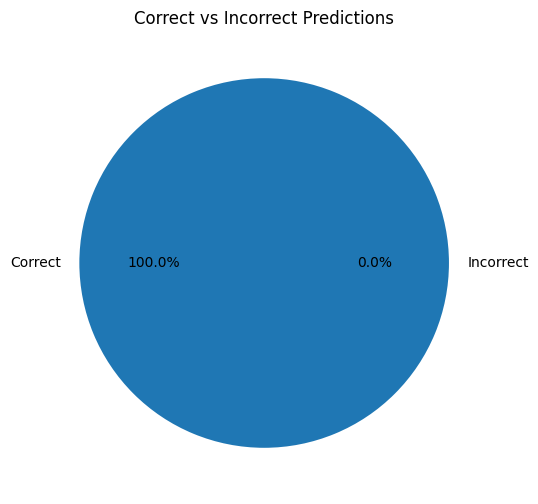

In [23]:

plt.figure(figsize=(6,6))

plt.pie(
    [correct, misclassified],
    labels=['Correct','Incorrect'],
    autopct='%1.1f%%'
)

plt.title(
    "Correct vs Incorrect Predictions"
)

plt.show()

## Conclusion

K-Nearest Neighbors (KNN) was implemented as the baseline classification model for spam message detection. Different K values were tested, and the optimal K was selected based on accuracy. The confusion matrix and classification report showed that the model effectively distinguished spam and legitimate messages. Distance metric analysis indicated how Euclidean and Manhattan distances affected performance. Although KNN achieved good classification results, its performance depended on the choice of K and distance metric, making parameter tuning important for optimal results